In [172]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [173]:
import matplotlib.pyplot as plt
import numpy as np

In [174]:
import pandas as pd

listings_file_path = '/content/drive/MyDrive/df_listings_explored.csv'
host_file_path = '/content/drive/MyDrive/df_host_explored.csv'
review_statistics_file_path = '/content/drive/MyDrive/df_reviews_explored.csv'

df_listings = pd.read_csv(listings_file_path)
df_host = pd.read_csv(host_file_path)
df_review_statistics = pd.read_csv(review_statistics_file_path)

In [175]:
df_listings.columns

Index(['id', 'last_scraped', 'source', 'description', 'picture_url', 'host_id',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_checkout_date',
       'price_quote_total_price', 'price_quote_price_per_night',
       'price_quote_raw', 'minimum_nights', 'maximum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability',
       'availability_30', 'availability_60', 'availability_90',
       'availability_365', 'availability_eoy', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d'],
      dtype='object')

#Driving factors behind listing price

Most listing prices are below 400, with the majority of listings being between 0-200. This section aims to investigate what factors effect the pricing of listings, such as which region or room type is the most expensive.

(array([1654., 1523., 1735., 1309.,  847.,  483.,  320.,  190.,  108.,
          90.,   45.,   36.,   22.,   13.,   13.,    7.,    6.,    3.,
           0.,    6.]),
 array([  2.72 ,  52.534, 102.348, 152.162, 201.976, 251.79 , 301.604,
        351.418, 401.232, 451.046, 500.86 , 550.674, 600.488, 650.302,
        700.116, 749.93 , 799.744, 849.558, 899.372, 949.186, 999.   ]),
 <BarContainer object of 20 artists>)

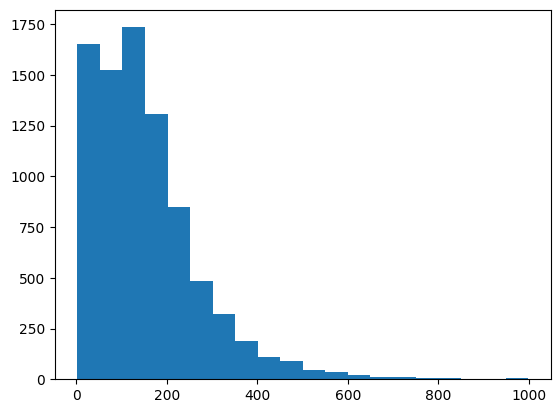

In [176]:
plt.hist(df_listings.loc[df_listings["price"] < 1000, "price"], bins=20)

Here we can see the spread of listings across Berlin. The plot shows a clear concentration of listings around the center of the city, with a dispersion of listings around the outside.

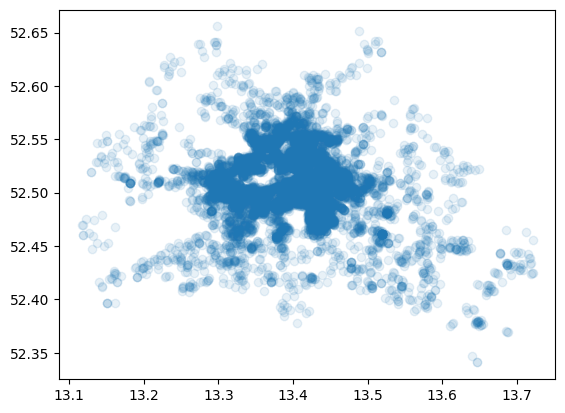

In [177]:
plt.scatter(df_listings["longitude"], df_listings["latitude"], alpha = 0.1)

In [178]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_listings[["long_std", "lat_std"]] = scaler.fit_transform(df_listings[["longitude", "latitude"]])

In [197]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.18, min_samples=100) # refined by experimentation
df_listings["cluster"] = dbscan.fit_predict(df_listings[["long_std", "lat_std"]])
df_listings["cluster"] = df_listings["cluster"].map({0: "Center", -1: "Outer Region"})
df_listings["cluster"].value_counts()

,count
cluster,
Center,10347
Outer Region,2373


By diving the data into two clusters, we can further understand how factors influence price across the two regions.

/tmp/ipykernel_1076/3908275914.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


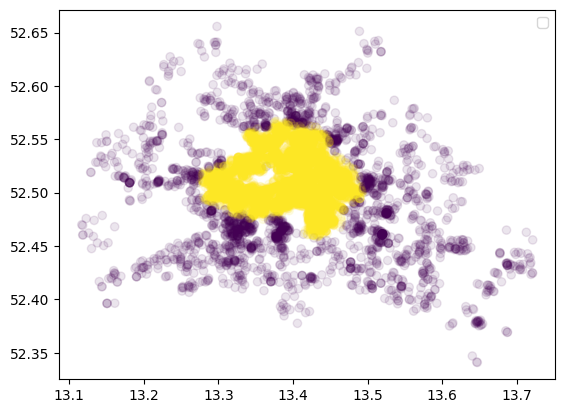

In [198]:
plt.scatter(df_listings["longitude"], df_listings["latitude"], alpha = 0.1, c=(df_listings["cluster"] == "Center"))
plt.legend()
plt.show()

By comparing the price across the two regions, we can see a significant difference in the average and median price. As expected, the central region accounts for more listings at a higher average price.

In [204]:
df_listings.groupby("cluster").agg({
    'price': ["mean", "median", "count",
              ("pct_missing", lambda x: round(x.isna().sum() / x.size * 100, 2))]
})

price                         
                    mean median count pct_missing
cluster                                          
Center        164.169655  139.0  6640       35.83
Outer Region  147.491627  106.5  1770       25.41

Looking closer at the difference between these region, there appears to be no significant difference in the listings other characteristics. In general, we can conclude that the difference in price is most likely due to location differences between the clusters and there are no other underlying factors.

In [226]:

df_listings.groupby("cluster").agg({
    'accommodates': ["mean", "median", "count",
              ("pct_missing", lambda x: round(x.isna().sum() / x.size * 100, 2))],
    'bathrooms': ["mean", "median", "count",
              ("pct_missing", lambda x: round(x.isna().sum() / x.size * 100, 2))],
    'bedrooms': ["mean", "median", "count",
              ("pct_missing", lambda x: round(x.isna().sum() / x.size * 100, 2))],
    'beds': ["mean", "median", "count",
              ("pct_missing", lambda x: round(x.isna().sum() / x.size * 100, 2))],
})

accommodates                           bathrooms               \
                     mean median  count pct_missing      mean median count   
cluster                                                                      
Center           3.133662    2.0  10347         0.0  1.173427    1.0  4783   
Outer Region     3.173198    2.0   2373         0.0  1.142209    1.0  1322   

                          bedrooms                               beds         \
             pct_missing      mean median count pct_missing      mean median   
cluster                                                                        
Center             53.77  1.476090    1.0  7570       26.84  2.235340    2.0   
Outer Region       44.29  1.589245    1.0  1748       26.34  2.279745    2.0   

                                
             count pct_missing  
cluster                         
Center        5082       50.88  
Outer Region  1412       40.50

The room type also does not differ across regions, with very similar percentages across types.

In [225]:
(df_listings.groupby("cluster")[['room_type']].value_counts(normalize=True)*100).round(2)

cluster       room_type      
Center        Entire home/apt    69.33
              Private room       29.21
              Shared room         0.80
              Hotel room          0.66
Outer Region  Entire home/apt    68.65
              Private room       30.30
              Hotel room          0.88
              Shared room         0.17
Name: proportion, dtype: float64

Having concluded that the difference between clusters is most likely due to location and not other environmental factors, we can further inspect the KPIs using metrics from the last 365 days.


The median price of a listing in the Center region is 30% higher than that of the outer region, while the median occupancy is the same across regions. Notably, the median revenue of a listing in the Center region is more than double the median revenue of a listing in the Outer Region (12922.0 vs 6240.0).

In total, across all listings the estimated revenue of the center region is nearly 5x as much as the estimated revenue (4.89x). Not only do listings in the center region alone make more money on average, but the larger number of listings in the center region (and perhaps greater availability/sustainability) also contributes to making the Center region a significantly more impactful source of revenue.

In [230]:
df_listings.groupby("cluster").agg({
    'price': ["mean", "median", "count", ],
    'estimated_occupancy_l365d': ["mean", "median", "count", ],
    'estimated_revenue_l365d': ["mean", "median", "count", "sum",],
})

price              estimated_occupancy_l365d                \
                    mean median count                      mean median  count   
cluster                                                                         
Center        164.169655  139.0  6640                 85.454045   25.0  10347   
Outer Region  147.491627  106.5  1770                 75.958281   25.0   2373   

             estimated_revenue_l365d                              
                                mean   median count          sum  
cluster                                                           
Center                  22247.956325  12922.0  6640  147726430.0  
Outer Region            14171.819774   6240.0  1770   25084121.0

In [231]:
df_listings = df_listings.merge(df_review_statistics, left_on="id", right_on="listing_id", how="left")

Review scores dont differ significantly by region. So we can explore the review scores impact on price without considering regional differences.

In [236]:
df_listings.groupby("cluster").agg({
    'number_of_reviews': ["mean", "median", "count", ],
    'review_scores_rating': ["mean", "median", "count", ],
    'review_scores_accuracy': ["mean", "median", "count",],
    'review_scores_cleanliness': ["mean", "median", "count"],
    'review_scores_location': ["mean", "median", "count",],
    'review_scores_value': ["mean", "median", "count",],
})

number_of_reviews               review_scores_rating         \
                          mean median  count                 mean median   
cluster                                                                    
Center               55.732676   11.0  10347             4.766160   4.86   
Outer Region         40.711336    9.0   2373             4.757228   4.87   

                   review_scores_accuracy               \
             count                   mean median count   
cluster                                                  
Center        8318               4.802553   4.89  8317   
Outer Region  1836               4.790561   4.89  1836   

             review_scores_cleanliness              review_scores_location  \
                                  mean median count                   mean   
cluster                                                                      
Center                        4.709473   4.81  8318               4.789322   
Outer Region                  4.726944   4.84  1836               4.675839   

                          review_scores_value               
             median count                mean median count  
cluster                                                     
Center         4.86  8316            4.654770   4.73  8316  
Outer Region   4.75  1836            4.638268   4.75  1836

In [267]:
df_listings["review_scores_rating"]

bins = [0] + list(round(x,1) for x in np.arange(4,5.1,0.1))
df_listings["review_scores_rating_binned"] = pd.cut(df_listings["review_scores_rating"], bins)

bins = list(np.arange(0,400,25)) + list(np.arange(400,1000,200))
df_listings["price_binned"] = pd.cut(df_listings["price"], bins)

Review scores generally stay consistent across price bins, with most bins having a median rating of 4.82-4.89. There are no notable outliers, the rating do appear to rise slightly above in the 600-800 price bin, but there are only 50 listings and the jump is not notable.

There are a few rises in the mean, however these are mostly for bins with fewer listings which are more vulnerable to outliers and have higher variance. interestingly, the first price bin has a mean of 4.7 but a median of 4.9 (which is relatively a big difference). This suggests a larger number of lower ratings for this bin, which is likely due to cheaper standards, however overall standards remain high.

In [278]:
df_listings.groupby("price_binned").agg({
    "review_scores_rating": ["mean", "median", "count", ],
   'estimated_occupancy_l365d': ["mean", "median", "count", ],
   'estimated_revenue_l365d': ["mean", "median", "count", "sum",
                               ("pct_of_revenue", lambda x: (x.sum()/df_listings["estimated_revenue_l365d"].sum()).round(2)*100)],
})

/tmp/ipykernel_1076/3632954673.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_listings.groupby("price_binned").agg({


review_scores_rating              estimated_occupancy_l365d  \
                             mean median count                      mean   
price_binned                                                               
(0, 25]                  4.696239   4.88   460                 32.569034   
(25, 50]                 4.714419   4.84   267                 38.655405   
(50, 75]                 4.739546   4.83   529                130.222405   
(75, 100]                4.779490   4.87   824                138.892222   
(100, 125]               4.744089   4.82   829                142.073661   
(125, 150]               4.752845   4.83   805                138.898364   
(150, 175]               4.726058   4.82   695                135.091768   
(175, 200]               4.738059   4.82   541                127.932409   
(200, 225]               4.753235   4.84   442                131.124481   
(225, 250]               4.747885   4.87   364                136.509091   
(250, 275]               4.778927   4.86   261                143.536496   
(275, 300]               4.770049   4.85   203                135.836364   
(300, 325]               4.830476   4.89   168                139.244444   
(325, 350]               4.748031   4.87   127                122.225352   
(350, 375]               4.796762   4.85   105                127.172727   
(375, 400]               4.835455   4.89    77                124.023810   
(400, 600]               4.755136   4.85   257                135.839286   
(600, 800]               4.868400   4.92    50                112.142857   

                          estimated_revenue_l365d                             \
             median count                    mean   median count         sum   
price_binned                                                                   
(0, 25]         0.0  1014              536.836292      0.0  1014    544352.0   
(25, 50]        0.0   592             1488.278716      0.0   592    881061.0   
(50, 75]      120.0   607             8497.494234   8197.0   607   5157979.0   
(75, 100]     126.0   900            12334.486667  11723.0   900  11101038.0   
(100, 125]    139.5   896            16008.820312  15875.5   896  14343903.0   
(125, 150]    139.0   856            19071.827103  18706.5   856  16325484.0   
(150, 175]    113.0   741            21960.846154  19399.0   741  16272987.0   
(175, 200]    101.0   577            23951.209705  19965.0   577  13819848.0   
(200, 225]    113.0   482            27860.280083  25086.0   482  13428655.0   
(225, 250]    126.0   385            32578.532468  29727.0   385  12542735.0   
(250, 275]    139.0   274            37553.299270  37667.5   274  10289604.0   
(275, 300]    126.0   220            38976.136364  35469.0   220   8574750.0   
(300, 325]    139.0   180            43623.616667  42731.0   180   7852251.0   
(325, 350]     94.5   142            41165.936620  31752.0   142   5845563.0   
(350, 375]    101.0   110            46249.409091  37673.0   110   5087435.0   
(375, 400]    126.0    84            48220.202381  48825.0    84   4050497.0   
(400, 600]    126.0   280            64523.917857  66474.0   280  18066697.0   
(600, 800]    101.0    56            75344.428571  68629.0    56   4219288.0   

                             
             pct_of_revenue  
price_binned                 
(0, 25]                 0.0  
(25, 50]                1.0  
(50, 75]                3.0  
(75, 100]               6.0  
(100, 125]              8.0  
(125, 150]              9.0  
(150, 175]              9.0  
(175, 200]              8.0  
(200, 225]              8.0  
(225, 250]              7.0  
(250, 275]              6.0  
(275, 300]              5.0  
(300, 325]              5.0  
(325, 350]              3.0  
(350, 375]              3.0  
(375, 400]              2.0  
(400, 600]             10.0  
(600, 800]              2.0

In [279]:
df_listings.groupby("review_scores_rating_binned").agg({
   "price" : ["mean", "median", "count", ],
   'estimated_occupancy_l365d': ["mean", "median", "count", ],
   'estimated_revenue_l365d': ["mean", "median", "count", "sum",
                               ("pct_of_revenue", lambda x: (x.sum()/df_listings["estimated_revenue_l365d"].sum()).round(2)*100)],
})

/tmp/ipykernel_1076/1930983718.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_listings.groupby("review_scores_rating_binned").agg({


price                \
                                   mean  median count   
review_scores_rating_binned                             
(0.0, 4.0]                   162.618594  136.60   249   
(4.0, 4.1]                   147.918095  128.00    21   
(4.1, 4.2]                   146.937733  134.00    75   
(4.2, 4.3]                   175.085398  156.50   113   
(4.3, 4.4]                   155.532886  140.75   201   
(4.4, 4.5]                   156.483445  135.00   328   
(4.5, 4.6]                   160.636192  142.25   386   
(4.6, 4.7]                   176.108371  152.05   706   
(4.7, 4.8]                   181.040964  139.00   954   
(4.8, 4.9]                   176.045316  148.00  1394   
(4.9, 5.0]                   176.082417  142.00  2606   

                            estimated_occupancy_l365d               \
                                                 mean median count   
review_scores_rating_binned                                          
(0.0, 4.0]                                  26.090909    0.0   396   
(4.0, 4.1]                                 122.037037  113.0    27   
(4.1, 4.2]                                  99.800000   63.0    95   
(4.2, 4.3]                                  95.918367   50.0   147   
(4.3, 4.4]                                  88.409420   39.0   276   
(4.4, 4.5]                                  85.083857   28.0   477   
(4.5, 4.6]                                 126.688000  113.0   500   
(4.6, 4.7]                                 130.288357  126.0   919   
(4.7, 4.8]                                 131.344111  126.0  1299   
(4.8, 4.9]                                 142.634239  151.0  1840   
(4.9, 5.0]                                  82.952911   38.0  4226   

                            estimated_revenue_l365d                 \
                                               mean   median count   
review_scores_rating_binned                                          
(0.0, 4.0]                              4723.317269   2457.0   249   
(4.0, 4.1]                             17255.523810  16072.0    21   
(4.1, 4.2]                             17562.733333  11110.0    75   
(4.2, 4.3]                             21036.265487  12817.0   113   
(4.3, 4.4]                             18831.925373  11175.0   201   
(4.4, 4.5]                             19018.969512  10132.0   328   
(4.5, 4.6]                             24707.150259  18786.0   386   
(4.6, 4.7]                             28838.307365  24462.0   706   
(4.7, 4.8]                             31988.708595  23482.0   954   
(4.8, 4.9]                             31390.248924  24614.5  1394   
(4.9, 5.0]                             20659.087874  11660.0  2606   

                                                        
                                    sum pct_of_revenue  
review_scores_rating_binned                             
(0.0, 4.0]                    1176106.0            1.0  
(4.0, 4.1]                     362366.0            0.0  
(4.1, 4.2]                    1317205.0            1.0  
(4.2, 4.3]                    2377098.0            1.0  
(4.3, 4.4]                    3785217.0            2.0  
(4.4, 4.5]                    6238222.0            4.0  
(4.5, 4.6]                    9536960.0            6.0  
(4.6, 4.7]                   20359845.0           12.0  
(4.7, 4.8]                   30517228.0           18.0  
(4.8, 4.9]                   43758007.0           25.0  
(4.9, 5.0]                   53837583.0           31.0

In [281]:
df_listings_host = df_listings.merge(df_host, on="host_id", how="left")